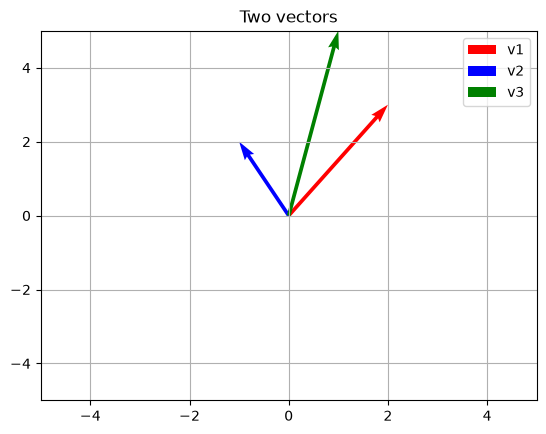

Manual dot product: 4
Numpy dot product: 4
Cosine similarity: 0.496
Cosine similarity (same direction): 1.000
Cosine similarity (perpendicular): 0.000
Cosine similarity (opposite direction): -1.000
Angle in rad math (math): 0.785
Angle in rad: 0.785
Original point: [1 0],  Rotated point: [0.70710678 0.70710678]


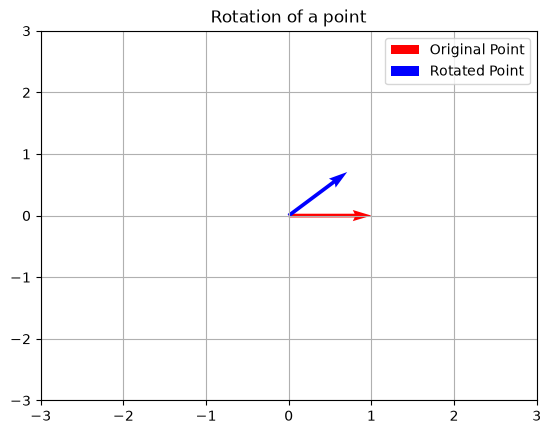

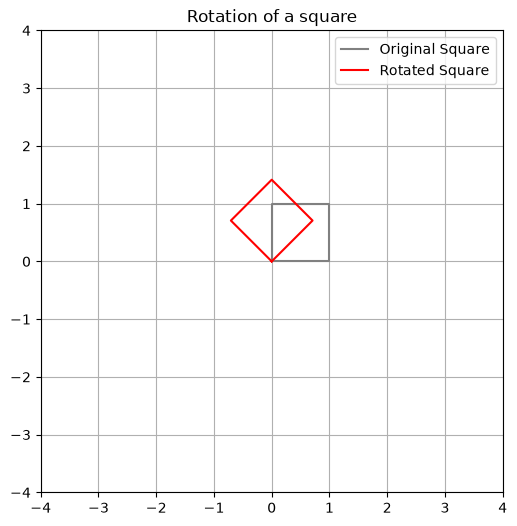

square points: [[0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]],  Rotated Rectangle point: [[ 0.          0.        ]
 [ 0.70710678  0.70710678]
 [ 0.          1.41421356]
 [-0.70710678  0.70710678]
 [ 0.          0.        ]]


In [13]:
import numpy as np
import matplotlib.pyplot as plt
v1=np.array([2, 3])
v2=np.array([-1, 2])
v3=v1 + v2
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='r', label='v1')
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='b', label='v2')
plt.quiver(0, 0, v3[0], v3[1], angles='xy', scale_units='xy', scale=1, color='g', label='v3')
plt.xlim(-5, 5); plt.ylim(-5, 5)
plt.grid(); plt.legend()
plt.title("Two vectors")
plt.show()

def dot_products(a,b):
    total=0
    for i in range(len(a)):
        total+=a[i]*b[i]
    return total

manual_dot=dot_products(v1,v2)
np_dot=np.dot(v1,v2)
print("Manual dot product:", manual_dot)
print("Numpy dot product:", np_dot)
assert manual_dot==np_dot, "Dot products do not match!"

# Cosine similarity — used constantly in ML (feature similarity, embeddings)
def cosine_similarity(a,b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))


print(f"Cosine similarity: {cosine_similarity(v1, v2):.3f}")

#Same direction vectors
s1=np.array([1, 1])
s2=np.array([2, 2])
print(f"Cosine similarity (same direction): {cosine_similarity(s1, s2):.3f}")   

#Perpendicular vectors
p1=np.array([1, 0])
p2=np.array([0, 1])
print(f"Cosine similarity (perpendicular): {cosine_similarity(p1, p2):.3f}")    

#Opposite direction vectors
o1=np.array([1, 0])
o2=np.array([-1, 0])
print(f"Cosine similarity (opposite direction): {cosine_similarity(o1, o2):.3f}")   

# A rotation matrix — this is exactly the math behind camera calibration/extrinsics
angle_deg=45
angle_rad_Math=angle_deg*np.pi/180
print(f"Angle in rad math (math): {angle_rad_Math:.3f}" )

angle_rad= np.radians(45)
print(f"Angle in rad: {angle_rad:.3f}" )
rotation_matrix=np.array([
                        [np.cos(angle_rad), -np.sin(angle_rad)], 
                        [np.sin(angle_rad), np.cos(angle_rad)]
                        ])

point=np.array([1,0])
rotated_point=rotation_matrix @ point
print(f"Original point: {point},  Rotated point: {rotated_point}")

fig,ax=plt.subplots()
ax.quiver(0, 0, point[0], point[1], angles='xy', scale_units='xy', scale=1, color='r', label='Original Point')
ax.quiver(0, 0, rotated_point[0], rotated_point[1], angles='xy', scale_units='xy', scale=1, color='b', label='Rotated Point')
ax.set_xlim(-3, 3); ax.set_ylim(-3,3)
ax.legend(); ax.grid(); ax.set_title("Rotation of a point")
plt.show()


#Sqaure points
square_points=np.array([[0,0], [1,0], [1,1],[0,1],[0,0]])
def rotate_rectangle(points, theta_deg):
    angle_rad=np.radians(theta_deg)
    rotation_matrix=np.array([
                        [np.cos(angle_rad), -np.sin(angle_rad)],
                        [np.sin(angle_rad), np.cos(angle_rad)]
                        ])
    return points @ rotation_matrix.T



fig,ax=plt.subplots(figsize=(6,6))    
rotated_rectangle=rotate_rectangle(square_points, 45)
ax.plot(square_points[:,0], square_points[:,1], 'gray', label='Original Square')
ax.plot(rotated_rectangle[:,0], rotated_rectangle[:,1], 'red', label='Rotated Square')
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.legend(); ax.grid(); ax.set_title("Rotation of a square");ax.set_aspect('equal')
plt.show()

print(f"square points: {square_points},  Rotated Rectangle point: {rotated_rectangle}")


